# GTZAN Unsupervised CNN Autoencoder

Reconstruction-only autoencoder on GTZAN mel spectrograms (no genre labels during training).

For the **multi-task** variant (reconstruction + genre loss), see `gtzan_autoencoder.ipynb`.
For a **supervised CNN baseline**, see `gtzan_cnn_baseline.ipynb`.

**Pipeline:**
1. Convert `GTZAN_Data/genres_original/<genre>/*.wav` into cached mel spectrogram `.npy` files.
2. Train a CNN autoencoder on normalized mel spectrograms (MSE only).
3. Evaluate the latent vectors with a linear probe, k-NN, silhouette, PCA, and UMAP.


In [32]:
!pip install librosa


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [33]:
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.neighbors import KNeighborsClassifier

try:
    import umap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

# Works when the notebook is run from src/ or from the project root.
NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD.parent if (NOTEBOOK_CWD.parent / 'GTZAN_Data').exists() else NOTEBOOK_CWD
GTZAN_ROOT = PROJECT_ROOT / 'GTZAN_Data'
AUDIO_DIR = GTZAN_ROOT / 'genres_original'
MEL_DIR = GTZAN_ROOT / 'melspecs'
MANIFEST_CSV = GTZAN_ROOT / 'features_30_sec.csv'
MEL_MANIFEST_CSV = GTZAN_ROOT / 'gtzan_mel_manifest.csv'
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

SAMPLE_RATE = 12000
N_FFT = 512
HOP_LENGTH = 256
N_MELS = 96
CROP_LENGTH = 1366
BATCH_SIZE = 16
RANDOM_STATE = 42

print(f'Project root: {PROJECT_ROOT}')
print(f'GTZAN root:   {GTZAN_ROOT}')
print(f'Audio dir:    {AUDIO_DIR}')
print(f'Mel cache:    {MEL_DIR}')
print(f'Manifest:     {MANIFEST_CSV}')

if not AUDIO_DIR.exists():
    raise FileNotFoundError(f'Expected GTZAN WAVs at {AUDIO_DIR}')
if not MANIFEST_CSV.exists():
    raise FileNotFoundError(f'Expected GTZAN manifest at {MANIFEST_CSV}')

Project root: /Users/logancostello/classes/csc/566/csc-566-final-project
GTZAN root:   /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data
Audio dir:    /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/genres_original
Mel cache:    /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/melspecs
Manifest:     /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/features_30_sec.csv


In [34]:
def crop_or_pad_mel(mel, crop_length=CROP_LENGTH):
    if mel.shape[1] > crop_length:
        start = (mel.shape[1] - crop_length) // 2
        mel = mel[:, start:start + crop_length]
    elif mel.shape[1] < crop_length:
        mel = np.pad(mel, ((0, 0), (0, crop_length - mel.shape[1])), mode='constant', constant_values=mel.min())
    return mel.astype(np.float32)


def wav_path_for_row(row):
    return AUDIO_DIR / row['label'] / row['filename']


def mel_path_for_row(row):
    return MEL_DIR / row['label'] / f"{Path(row['filename']).stem}.npy"


def wav_to_mel(wav_path):
    y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel_power, ref=np.max)
    return crop_or_pad_mel(mel_db)


def build_mel_cache(force=False):
    df = pd.read_csv(MANIFEST_CSV)
    rows = []
    bad_files = []

    MEL_DIR.mkdir(parents=True, exist_ok=True)
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Building mel cache'):
        wav_path = wav_path_for_row(row)
        mel_path = mel_path_for_row(row)
        mel_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            if force or not mel_path.exists():
                mel = wav_to_mel(wav_path)
                np.save(mel_path, mel)
            rows.append({
                'filename': row['filename'],
                'label': row['label'],
                'wav_path': str(wav_path),
                'mel_path': str(mel_path),
            })
        except Exception as exc:
            bad_files.append((str(wav_path), str(exc)))

    manifest_df = pd.DataFrame(rows)
    manifest_df.to_csv(MEL_MANIFEST_CSV, index=False)

    print(f'Cached/verified mels: {len(manifest_df)}')
    if bad_files:
        print(f'Skipped unreadable files: {len(bad_files)}')
        for path, err in bad_files[:5]:
            print(f'  {path}: {err}')
    print(f'Mel manifest saved to: {MEL_MANIFEST_CSV}')
    return manifest_df


manifest_df = build_mel_cache(force=False)
display(manifest_df.head())

Building mel cache:  26%|██▌       | 257/1000 [00:00<00:00, 2566.89it/s]/var/folders/48/xc_7wg310fs611jzn1rpqqpm0000gn/T/ipykernel_33704/1560538226.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
/Users/logancostello/.pyenv/versions/3.13.1/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Building mel cache: 100%|██████████| 1000/1000 [00:00<00:00, 2823.93it/s]


Cached/verified mels: 999
Skipped unreadable files: 1
  /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/genres_original/jazz/jazz.00054.wav: 
Mel manifest saved to: /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/gtzan_mel_manifest.csv


,filename,label,wav_path,mel_path
0,blues.00000.wav,blues,/Users/logancostello/classes/csc/566/csc-566-f...,/Users/logancostello/classes/csc/566/csc-566-f...
1,blues.00001.wav,blues,/Users/logancostello/classes/csc/566/csc-566-f...,/Users/logancostello/classes/csc/566/csc-566-f...
2,blues.00002.wav,blues,/Users/logancostello/classes/csc/566/csc-566-f...,/Users/logancostello/classes/csc/566/csc-566-f...
3,blues.00003.wav,blues,/Users/logancostello/classes/csc/566/csc-566-f...,/Users/logancostello/classes/csc/566/csc-566-f...
4,blues.00004.wav,blues,/Users/logancostello/classes/csc/566/csc-566-f...,/Users/logancostello/classes/csc/566/csc-566-f...


In [35]:
genres = sorted(manifest_df['label'].unique())
genre_to_idx = {genre: i for i, genre in enumerate(genres)}
idx_to_genre = {i: genre for genre, i in genre_to_idx.items()}

tracks = manifest_df[['filename', 'label']].drop_duplicates()

train_val_tracks, test_tracks = train_test_split(
    tracks,
    test_size=0.20,
    stratify=tracks['label'],
    random_state=RANDOM_STATE,
)
train_tracks, val_tracks = train_test_split(
    train_val_tracks,
    test_size=0.20,
    stratify=train_val_tracks['label'],
    random_state=RANDOM_STATE,
)

train_df = manifest_df[manifest_df['filename'].isin(train_tracks['filename'])].reset_index(drop=True)
val_df   = manifest_df[manifest_df['filename'].isin(val_tracks['filename'])].reset_index(drop=True)
test_df  = manifest_df[manifest_df['filename'].isin(test_tracks['filename'])].reset_index(drop=True)

print(f'Genres: {genres}')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Train class counts:')
print(train_df['label'].value_counts().sort_index())


def compute_mel_stats(df):
    total = 0
    sum_x = 0.0
    sum_x2 = 0.0
    for mel_path in tqdm(df['mel_path'], desc='Computing train mel stats'):
        mel = np.load(mel_path).astype(np.float64)
        total += mel.size
        sum_x += mel.sum()
        sum_x2 += np.square(mel).sum()
    mean = sum_x / total
    var = max(sum_x2 / total - mean ** 2, 1e-8)
    return float(mean), float(np.sqrt(var))


mel_mean, mel_std = compute_mel_stats(train_df)
print(f'Train mel mean: {mel_mean:.4f} | std: {mel_std:.4f}')


class GTZANDataset(Dataset):
    def __init__(self, df, genre_to_idx, mel_mean, mel_std):
        self.df = df.reset_index(drop=True)
        self.genre_to_idx = genre_to_idx
        self.mel_mean = mel_mean
        self.mel_std = mel_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row['mel_path']).astype(np.float32)
        mel = (mel - self.mel_mean) / self.mel_std
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.genre_to_idx[row['label']], dtype=torch.long)
        return mel, label


def make_loaders(batch_size=BATCH_SIZE):
    train_ds = GTZANDataset(train_df, genre_to_idx, mel_mean, mel_std)
    val_ds = GTZANDataset(val_df, genre_to_idx, mel_mean, mel_std)
    test_ds = GTZANDataset(test_df, genre_to_idx, mel_mean, mel_std)

    loader_kwargs = dict(batch_size=batch_size, num_workers=0, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders()
mels, labels = next(iter(train_loader))
print(f'Batch mels: {mels.shape} | labels: {labels.shape}')

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train: 639 | Val: 160 | Test: 200
Train class counts:
label
blues        64
classical    64
country      64
disco        64
hiphop       64
jazz         63
metal        64
pop          64
reggae       64
rock         64
Name: count, dtype: int64


Computing train mel stats: 100%|██████████| 639/639 [00:00<00:00, 896.58it/s] 


Train mel mean: -39.6145 | std: 13.8895
Batch mels: torch.Size([16, 1, 96, 1366]) | labels: torch.Size([16])


In [36]:
class GenreAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
        )

        self.flatten_dim = 512 * 12 * 21
        self.fc_enc = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(128, 1, kernel_size=3, padding=1),
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc_enc(x)

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 512, 12, 21)
        x = self.decoder(x)
        if x.shape[-1] < CROP_LENGTH:
            x = nn.functional.pad(x, (0, CROP_LENGTH - x.shape[-1]))
        return x[:, :, :N_MELS, :CROP_LENGTH]

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


_probe = GenreAutoencoder(latent_dim=128)
_probe_x = torch.randn(2, 1, N_MELS, CROP_LENGTH)
_probe_recon, _probe_z = _probe(_probe_x)
print(f'Input:  {_probe_x.shape}')
print(f'Recon:  {_probe_recon.shape}')
print(f'Latent: {_probe_z.shape}')


Input:  torch.Size([2, 1, 96, 1366])
Recon:  torch.Size([2, 1, 96, 1366])
Latent: torch.Size([2, 128])


Using device: mps


Epoch 1/20 train: 100%|██████████| 40/40 [01:41<00:00,  2.54s/it]


Epoch 1/20 | train 23.9218 | val 0.7667
  → saved checkpoints/gtzan_unsupervised_ae_best.pth (val loss 0.7667)


Epoch 2/20 train: 100%|██████████| 40/40 [01:11<00:00,  1.79s/it]


Epoch 2/20 | train 0.7379 | val 0.7218
  → saved checkpoints/gtzan_unsupervised_ae_best.pth (val loss 0.7218)


...

Epoch 19/20 train: 100%|██████████| 40/40 [01:24<00:00,  2.11s/it]


Epoch 19/20 | train 0.3813 | val 0.4175


Epoch 20/20 train: 100%|██████████| 40/40 [01:19<00:00,  1.98s/it]


Epoch 20/20 | train 0.3789 | val 0.4079
  → saved checkpoints/gtzan_unsupervised_ae_best.pth (val loss 0.4079)


,epoch,train_loss,val_loss
15,16,0.385230,0.409885
16,17,0.382176,0.414452
17,18,0.380480,0.408717
18,19,0.381332,0.417497
19,20,0.378904,0.407950


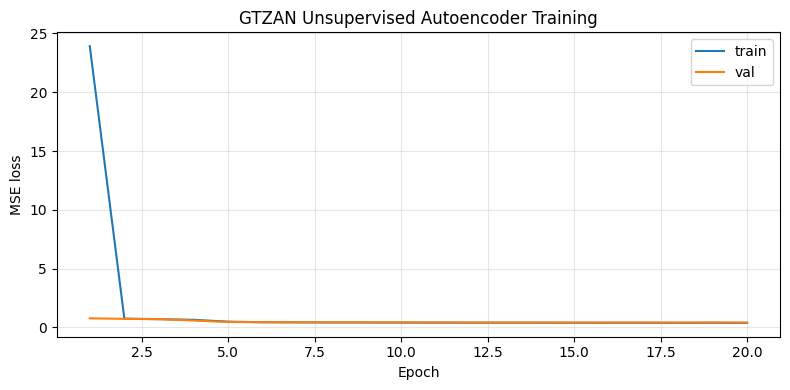

In [37]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

LATENT_DIM = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BEST_MODEL_PATH = CHECKPOINT_DIR / 'gtzan_unsupervised_ae_best.pth'

model = GenreAutoencoder(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

best_val_loss = float('inf')
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for mels, _ in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS} train'):
        mels = mels.to(device)
        optimizer.zero_grad()
        recon, _ = model(mels)
        loss = criterion(recon, mels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for mels, _ in val_loader:
            mels = mels.to(device)
            recon, _ = model(mels)
            loss = criterion(recon, mels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss})

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | train {train_loss:.4f} | val {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  → saved {BEST_MODEL_PATH} (val loss {val_loss:.4f})')

history_df = pd.DataFrame(history)
display(history_df.tail())

plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('GTZAN Unsupervised Autoencoder Training')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


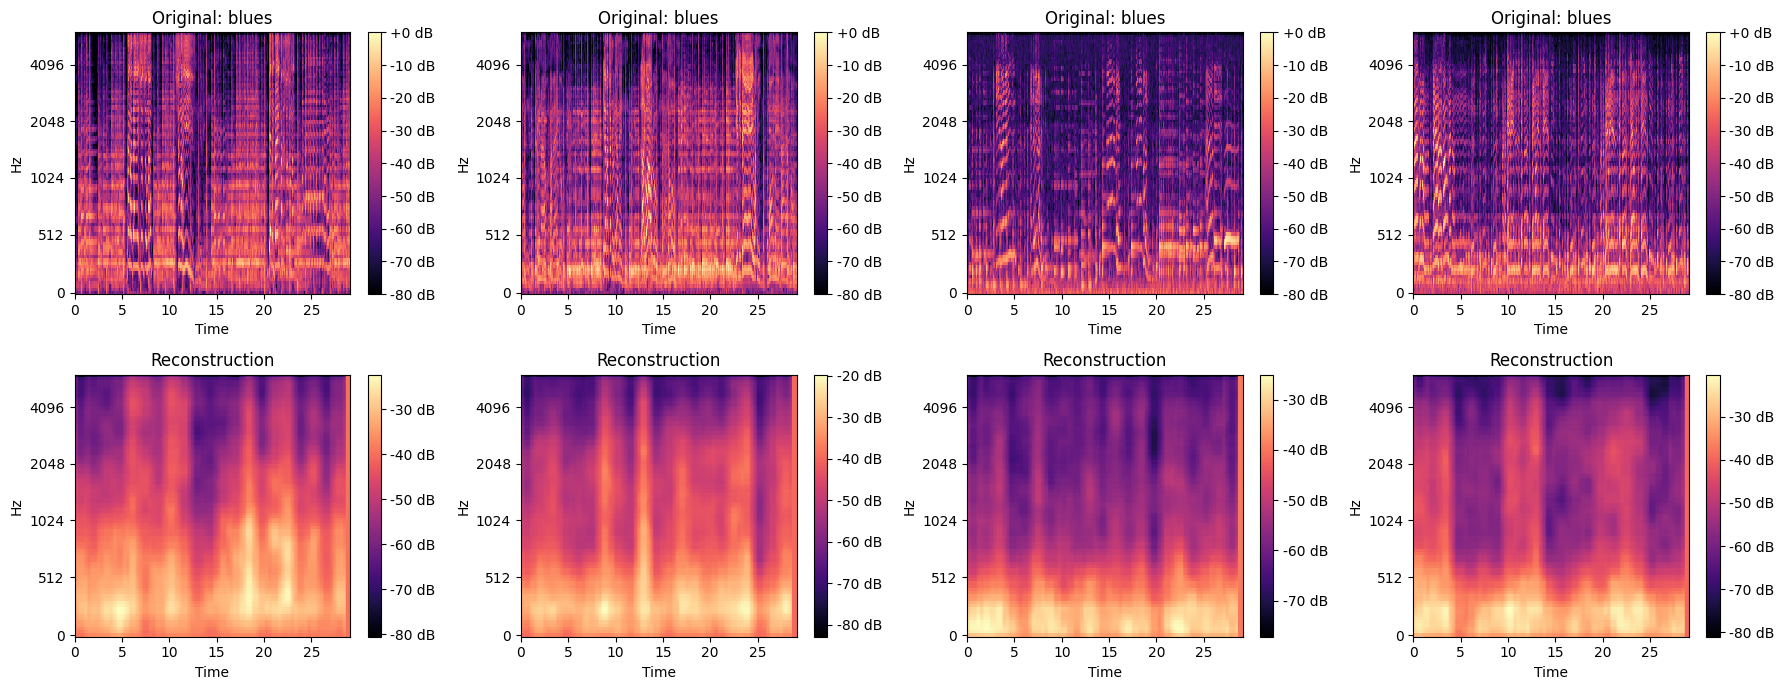

In [38]:
# Visualize reconstruction quality on validation examples
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

mels, labels = next(iter(val_loader))
mels = mels.to(device)
with torch.no_grad():
    recon, _ = model(mels)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i in range(4):
    orig = (mels[i, 0].cpu().numpy() * mel_std) + mel_mean
    rec = (recon[i, 0].cpu().numpy() * mel_std) + mel_mean
    genre = idx_to_genre[int(labels[i])]
    for ax, data, title in zip(axes[:, i], [orig, rec], [f'Original: {genre}', 'Reconstruction']):
        img = librosa.display.specshow(data, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=ax)
        ax.set_title(title)
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()


In [39]:
@torch.no_grad()
def collect_embeddings(loader):
    model.eval()
    embeddings = []
    labels = []
    for mels, batch_labels in tqdm(loader, desc='Extracting embeddings'):
        z = model.encode(mels.to(device))
        embeddings.append(z.cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings, axis=0), np.concatenate(labels, axis=0)


train_embeddings, train_labels = collect_embeddings(train_loader)
val_embeddings, val_labels = collect_embeddings(val_loader)
test_embeddings, test_labels = collect_embeddings(test_loader)

print(f'Train embeddings: {train_embeddings.shape}')
print(f'Val embeddings:   {val_embeddings.shape}')
print(f'Test embeddings:  {test_embeddings.shape}')

Extracting embeddings: 100%|██████████| 13/13 [00:03<00:00,  4.11it/s]

Train embeddings: (639, 128)
Val embeddings:   (160, 128)
Test embeddings:  (200, 128)


In [40]:
# Quantitative latent-space checks (labels used for evaluation only)
probe = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
probe.fit(train_embeddings, train_labels)
probe_pred = probe.predict(test_embeddings)
probe_acc = accuracy_score(test_labels, probe_pred)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_embeddings, train_labels)
knn_pred = knn.predict(test_embeddings)
knn_acc = accuracy_score(test_labels, knn_pred)

all_embeddings = np.concatenate([train_embeddings, val_embeddings, test_embeddings], axis=0)
all_labels = np.concatenate([train_labels, val_labels, test_labels], axis=0)
sil_score = silhouette_score(all_embeddings, all_labels)

metrics_df = pd.DataFrame([
    {'metric': 'linear_probe_test_accuracy', 'value': probe_acc},
    {'metric': 'knn_5_test_accuracy', 'value': knn_acc},
    {'metric': 'latent_silhouette_score', 'value': sil_score},
    {'metric': 'best_val_reconstruction_mse', 'value': best_val_loss},
])
display(metrics_df)

print('Linear probe classification report:')
print(classification_report(test_labels, probe_pred, target_names=genres))


,metric,value
0,linear_probe_test_accuracy,0.460000
1,knn_5_test_accuracy,0.355000
2,latent_silhouette_score,-0.078223
3,best_val_reconstruction_mse,0.407950


Linear probe classification report:
              precision    recall  f1-score   support

       blues       0.38      0.15      0.21        20
   classical       0.79      0.75      0.77        20
     country       0.35      0.40      0.37        20
       disco       0.33      0.25      0.29        20
      hiphop       0.39      0.45      0.42        20
        jazz       0.34      0.50      0.41        20
       metal       0.76      0.65      0.70        20
         pop       0.52      0.60      0.56        20
      reggae       0.55      0.60      0.57        20
        rock       0.24      0.25      0.24        20

    accuracy                           0.46       200
   macro avg       0.47      0.46      0.45       200
weighted avg       0.47      0.46      0.45       200



PCA variance explained: 58.4%


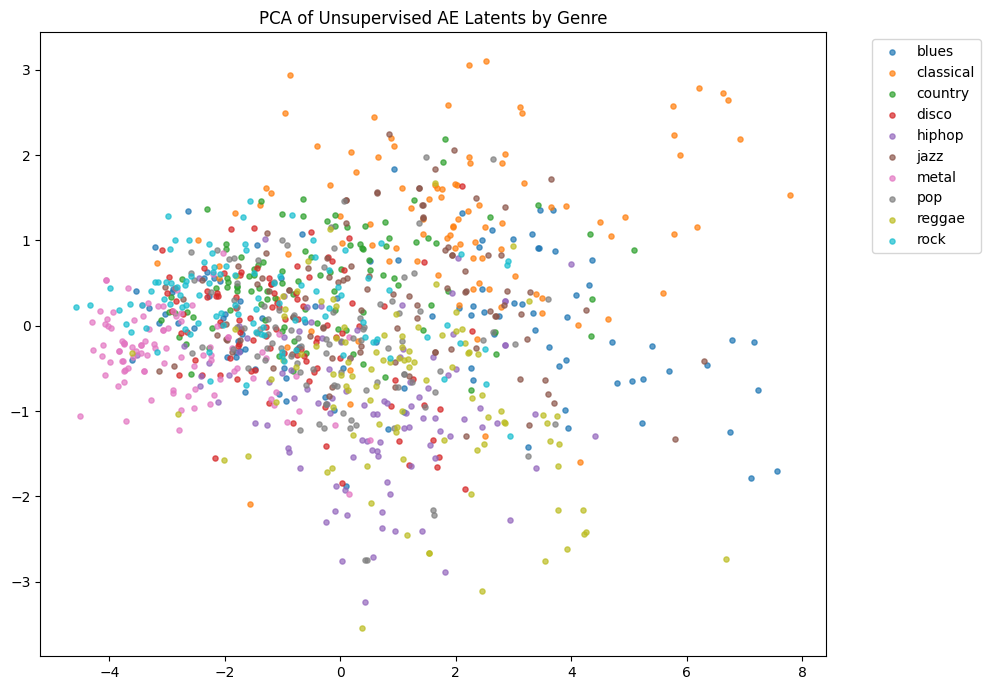

/Users/logancostello/.pyenv/versions/3.13.1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


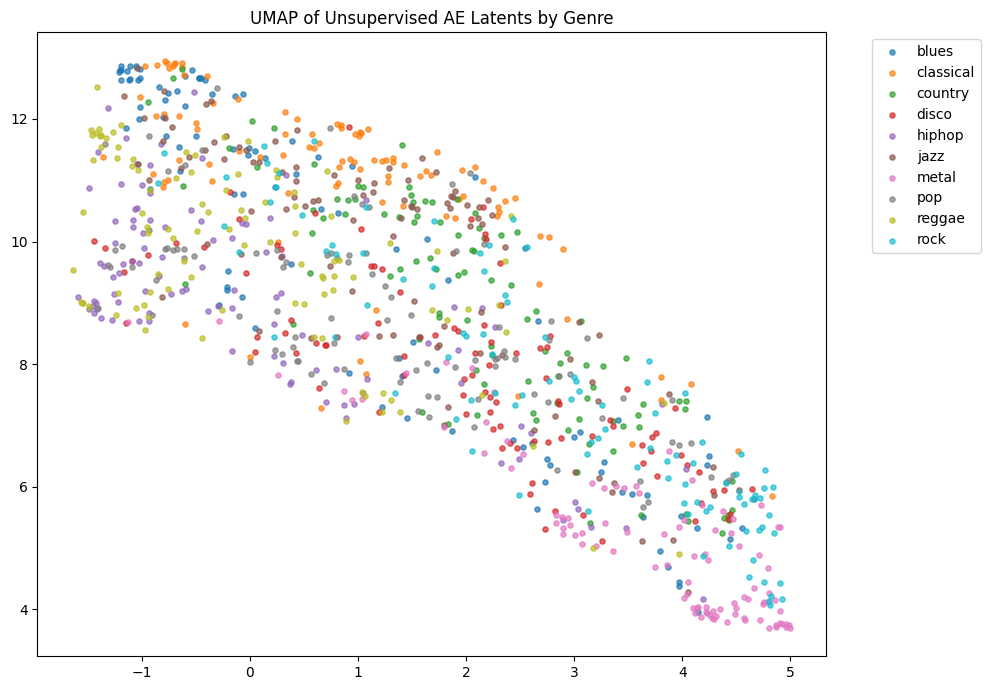

In [41]:
# PCA / UMAP latent visualizations colored by genre
def plot_embedding_2d(points, labels, title):
    plt.figure(figsize=(10, 7))
    for genre_idx, genre in idx_to_genre.items():
        mask = labels == genre_idx
        plt.scatter(points[mask, 0], points[mask, 1], s=14, alpha=0.7, label=genre)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(all_embeddings)
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%')
plot_embedding_2d(pca_points, all_labels, 'PCA of Unsupervised AE Latents by Genre')

reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=RANDOM_STATE)
umap_points = reducer.fit_transform(all_embeddings)
plot_embedding_2d(umap_points, all_labels, 'UMAP of Unsupervised AE Latents by Genre')


In [42]:
import torch.nn.functional as F

class LatentProbeNet(nn.Module):
    def __init__(self, latent_dim, num_classes, hidden=32, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# Convert embeddings to tensors
X_train = torch.tensor(train_embeddings, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_test  = torch.tensor(test_embeddings, dtype=torch.float32)
y_test  = torch.tensor(test_labels, dtype=torch.long)

probe_ds_train = torch.utils.data.TensorDataset(X_train, y_train)
probe_ds_test  = torch.utils.data.TensorDataset(X_test, y_test)
probe_train_loader = DataLoader(probe_ds_train, batch_size=32, shuffle=True)
probe_test_loader  = DataLoader(probe_ds_test,  batch_size=32, shuffle=False)

PROBE_EPOCHS = 50
PROBE_LR = 1e-3
PROBE_MODEL_PATH = CHECKPOINT_DIR / 'gtzan_unsupervised_ae_probe.pth'

probe_model = LatentProbeNet(latent_dim=LATENT_DIM, num_classes=len(genres)).to(device)
probe_optimizer = torch.optim.Adam(probe_model.parameters(), lr=PROBE_LR, weight_decay=1e-4)
probe_criterion = nn.CrossEntropyLoss()

best_probe_val_acc = 0.0
probe_history = []

# Use val embeddings for checkpointing
X_val = torch.tensor(val_embeddings, dtype=torch.float32)
y_val = torch.tensor(val_labels, dtype=torch.long)
probe_ds_val = torch.utils.data.TensorDataset(X_val, y_val)
probe_val_loader = DataLoader(probe_ds_val, batch_size=32, shuffle=False)

for epoch in range(PROBE_EPOCHS):
    probe_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in probe_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        probe_optimizer.zero_grad()
        logits = probe_model(xb)
        loss = probe_criterion(logits, yb)
        loss.backward()
        probe_optimizer.step()
        train_loss += loss.item() * xb.size(0)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += xb.size(0)

    probe_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for xb, yb in probe_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = probe_model(xb).argmax(1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    train_acc = train_correct / train_total
    val_acc   = val_correct / val_total
    probe_history.append({'epoch': epoch + 1, 'train_acc': train_acc, 'val_acc': val_acc})

    if val_acc > best_probe_val_acc:
        best_probe_val_acc = val_acc
        torch.save(probe_model.state_dict(), PROBE_MODEL_PATH)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{PROBE_EPOCHS} | train acc {train_acc:.4f} | val acc {val_acc:.4f}')

print(f'Best probe val acc: {best_probe_val_acc:.4f}')

Epoch 10/50 | train acc 0.4366 | val acc 0.4250
Epoch 20/50 | train acc 0.5055 | val acc 0.4500
Epoch 30/50 | train acc 0.5712 | val acc 0.4875
Epoch 40/50 | train acc 0.5618 | val acc 0.5000
Epoch 50/50 | train acc 0.5915 | val acc 0.5188
Best probe val acc: 0.5188


Test accuracy (unsupervised AE + NN probe): 0.4550
              precision    recall  f1-score   support

       blues       0.56      0.25      0.34        20
   classical       0.75      0.60      0.67        20
     country       0.46      0.30      0.36        20
       disco       0.28      0.25      0.26        20
      hiphop       0.43      0.50      0.47        20
        jazz       0.36      0.70      0.47        20
       metal       0.71      0.60      0.65        20
         pop       0.46      0.55      0.50        20
      reggae       0.50      0.50      0.50        20
        rock       0.29      0.30      0.29        20

    accuracy                           0.46       200
   macro avg       0.48      0.45      0.45       200
weighted avg       0.48      0.46      0.45       200



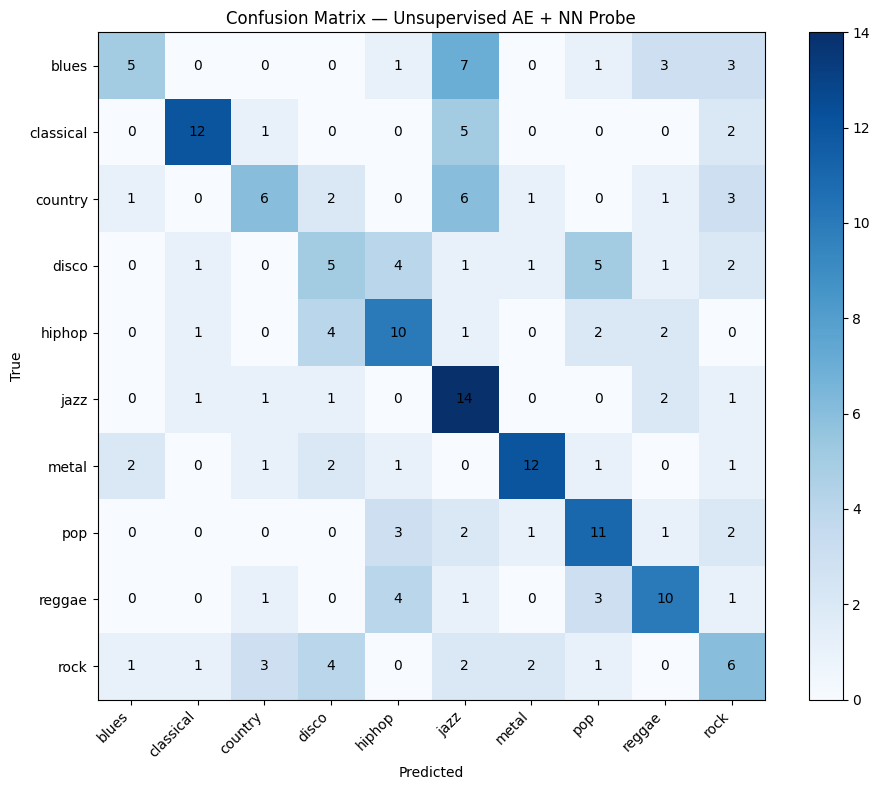

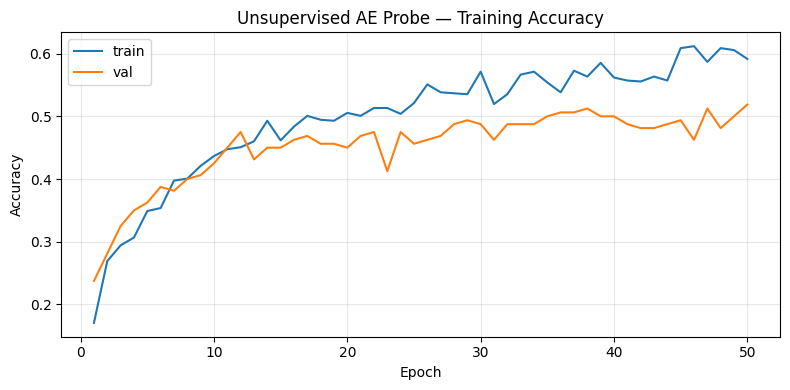

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

probe_model.load_state_dict(torch.load(PROBE_MODEL_PATH, map_location=device, weights_only=True))
probe_model.eval()

all_preds, all_labels_eval = [], []
with torch.no_grad():
    for xb, yb in probe_test_loader:
        logits = probe_model(xb.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels_eval.extend(yb.numpy())

all_preds       = np.array(all_preds)
all_labels_eval = np.array(all_labels_eval)
test_acc = (all_preds == all_labels_eval).mean()

print(f'Test accuracy (unsupervised AE + NN probe): {test_acc:.4f}')
print(classification_report(all_labels_eval, all_preds, target_names=genres))

cm = confusion_matrix(all_labels_eval, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(genres)), genres, rotation=45, ha='right')
ax.set_yticks(range(len(genres)), genres)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Unsupervised AE + NN Probe')
for i in range(len(genres)):
    for j in range(len(genres)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

# Training curve
probe_history_df = pd.DataFrame(probe_history)
plt.figure(figsize=(8, 4))
plt.plot(probe_history_df['epoch'], probe_history_df['train_acc'], label='train')
plt.plot(probe_history_df['epoch'], probe_history_df['val_acc'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Unsupervised AE Probe — Training Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()